# Digital Marketing ConversionRate Analysis — Clean Version

## Goal

This notebook applies Day 1 Machine Learning and Linear Regression concepts to a digital marketing dataset.

The main target is:

`ConversionRate`

The goal is to understand whether customer, campaign, and engagement features can predict conversion rate.

## Final message for presentation

This notebook shows the full professional workflow:

1. Load and inspect the data  
2. Check data quality  
3. Explore key relationships visually  
4. Apply basic statistics concepts  
5. Build Simple Linear Regression  
6. Build Multiple Linear Regression  
7. Add categorical features using one-hot encoding  
8. Compare models and explain the business meaning

In [1]:
#%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels
#%pip install statsmodels
#%pip install scikit-learn

# 1. Setup

This cell imports the libraries needed for the analysis.

Run the install line only if the packages are missing in your environment.

In [2]:
# Install packages only if needed.
# If everything already works, you can leave this line commented.
# %pip install kagglehub pandas numpy matplotlib seaborn scikit-learn

# Download Kaggle dataset
import kagglehub

# File handling
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load Dataset from KaggleHub

I am using KaggleHub to download the dataset directly from Kaggle.

KaggleHub returns a folder path, so I search inside that folder for the CSV file.

In [3]:
# Download the latest version of the dataset from Kaggle.
path = kagglehub.dataset_download(
    "rabieelkharoua/predict-conversion-in-digital-marketing-dataset"
)

# Convert the downloaded path into a Path object.
dataset_path = Path(path)

# Find CSV files inside the downloaded dataset folder.
csv_files = list(dataset_path.rglob("*.csv"))

# Load the first CSV file found.
csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("CSV used:", csv_path)
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
CSV used: /Users/ruturajmokashi/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1/digital_marketing_campaign_dataset.csv
Dataset shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,"6,497.8701",0.0439,0.0880,0,2.3990,7.3968,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,"3,898.6686",0.1557,0.1827,42,2.9171,5.3525,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,"1,546.4296",0.2775,0.0764,2,8.2236,13.7949,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.5259,0.1376,0.0880,47,4.5409,14.6884,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,"1,678.0436",0.2529,0.1099,0,2.0468,13.9934,6,6,6,8,4345,IsConfid,ToolConfid,1


# 3. Quick Data Inspection

Before modeling, I check the structure and quality of the dataset.

This tells me:

- number of rows and columns
- column names
- data types
- missing values
- duplicate rows

In [4]:
# Basic structure of the dataset
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

# Data quality checks
print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(8000, 20)

Column names:
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']

Data types:


CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object


Total missing values:
0

Duplicate rows:
0


## Data Quality Summary

The dataset contains 8,000 rows and 20 columns.

The basic quality check shows:

- no missing values
- no duplicate rows

This means the dataset is ready for analysis without missing-value cleaning.

# 4. Business Understanding of Columns

I group columns into business categories so the analysis is easier to understand.

This step does not change the data. It only helps organize thinking.

In [5]:
# Customer profile features
customer_profile_cols = [
    "Age", "Gender", "Income", "PreviousPurchases", "LoyaltyPoints"
]

# Campaign-related features
campaign_cols = [
    "CampaignChannel", "CampaignType", "AdSpend"
]

# Engagement-related features
engagement_cols = [
    "ClickThroughRate", "WebsiteVisits", "PagesPerVisit", "TimeOnSite",
    "SocialShares", "EmailOpens", "EmailClicks"
]

# Target columns
target_cols = ["ConversionRate", "Conversion"]

# Technical columns that should not be used as predictive features
technical_cols = ["CustomerID", "AdvertisingPlatform", "AdvertisingTool"]

print("Customer profile columns:", customer_profile_cols)
print("Campaign columns:", campaign_cols)
print("Engagement columns:", engagement_cols)
print("Target columns:", target_cols)
print("Technical columns:", technical_cols)

Customer profile columns: ['Age', 'Gender', 'Income', 'PreviousPurchases', 'LoyaltyPoints']
Campaign columns: ['CampaignChannel', 'CampaignType', 'AdSpend']
Engagement columns: ['ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks']
Target columns: ['ConversionRate', 'Conversion']
Technical columns: ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool']


# 5. Target Variable

For regression, the target variable is:

`ConversionRate`

Reason:

`ConversionRate` is numeric and continuous.

The dataset also has `Conversion`, but that is a binary 0/1 column. It is better for classification, not standard Linear Regression.

In [6]:
# Check target variable summary
print("ConversionRate summary:")
display(df["ConversionRate"].describe())

print("\nConversion counts:")
display(df["Conversion"].value_counts())

print("\nConversion percentage:")
display(df["Conversion"].value_counts(normalize=True) * 100)

ConversionRate summary:


count   8,000.0000
mean        0.1044
std         0.0549
min         0.0100
25%         0.0564
50%         0.1040
75%         0.1521
max         0.2000
Name: ConversionRate, dtype: float64


Conversion counts:


Conversion
1    7012
0     988
Name: count, dtype: int64


Conversion percentage:


Conversion
1   87.6500
0   12.3500
Name: proportion, dtype: float64

# 6. Quick Visual Exploration

I use simple charts to understand:

- the distribution of `ConversionRate`
- the distribution of `AdSpend`
- the relationship between `AdSpend` and `ConversionRate`

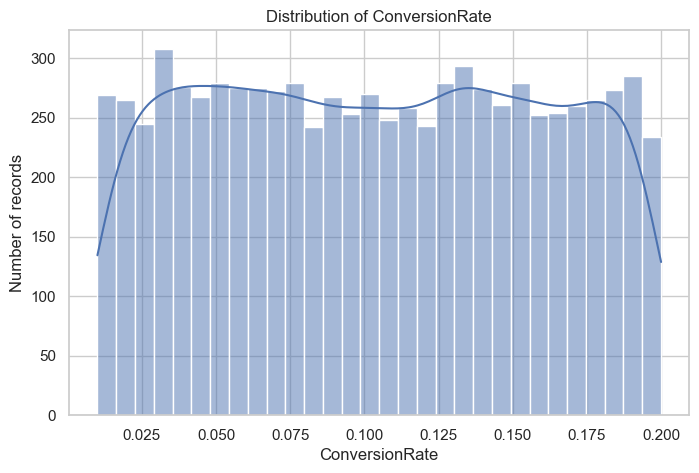

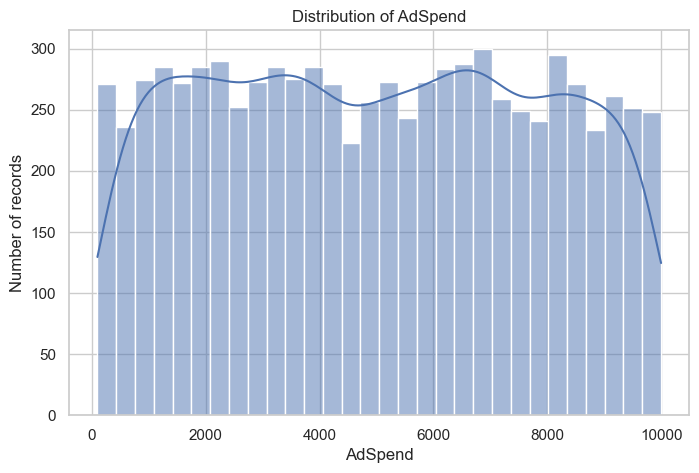

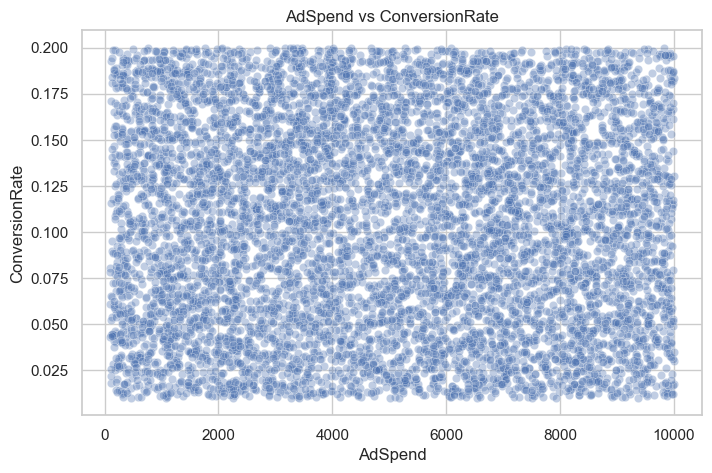

In [7]:
# Distribution of ConversionRate
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="ConversionRate", bins=30, kde=True)
plt.title("Distribution of ConversionRate")
plt.xlabel("ConversionRate")
plt.ylabel("Number of records")
plt.show()

# Distribution of AdSpend
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="AdSpend", bins=30, kde=True)
plt.title("Distribution of AdSpend")
plt.xlabel("AdSpend")
plt.ylabel("Number of records")
plt.show()

# Scatter plot: AdSpend vs ConversionRate
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="AdSpend", y="ConversionRate", alpha=0.35)
plt.title("AdSpend vs ConversionRate")
plt.xlabel("AdSpend")
plt.ylabel("ConversionRate")
plt.show()

## Visual Insight

The scatter plot does not show a strong linear relationship between `AdSpend` and `ConversionRate`.

This means `AdSpend` alone may not be a strong predictor of conversion rate.

# 7. Day 1 Statistics Concepts

Here I apply basic statistics concepts using `AdSpend`.

These concepts connect directly to what we learned today:

- Sum
- Mean
- Deviation
- Variance
- Standard deviation
- Covariance
- Correlation

In [8]:
# Choose one important marketing column
column = "AdSpend"

# Sum: total advertising spend
adspend_sum = df[column].sum()

# Mean: average advertising spend
adspend_mean = df[column].mean()

# Deviation: each row's AdSpend minus average AdSpend
df["AdSpend_Deviation"] = df[column] - adspend_mean

# Variance: spread of AdSpend values
adspend_variance = df[column].var()

# Standard deviation: typical distance from the average
adspend_std = df[column].std()

# Covariance and correlation with ConversionRate
cov_adspend_conversionrate = df["AdSpend"].cov(df["ConversionRate"])
corr_adspend_conversionrate = df["AdSpend"].corr(df["ConversionRate"])

print("AdSpend statistics")
print("------------------")
print("Sum:", adspend_sum)
print("Mean:", adspend_mean)
print("Variance:", adspend_variance)
print("Standard deviation:", adspend_std)

print("\nRelationship with ConversionRate")
print("--------------------------------")
print("Covariance:", cov_adspend_conversionrate)
print("Correlation:", corr_adspend_conversionrate)

display(df[["AdSpend", "AdSpend_Deviation"]].head())

AdSpend statistics
------------------
Sum: 40007558.64339962
Mean: 5000.944830424953
Variance: 8054460.556350094
Standard deviation: 2838.038152729821

Relationship with ConversionRate
--------------------------------
Covariance: -3.143723664613924
Correlation: -0.02018484713330237


,AdSpend,AdSpend_Deviation
0,"6,497.8701","1,496.9252"
1,"3,898.6686","-1,102.2762"
2,"1,546.4296","-3,454.5152"
3,539.5259,"-4,461.4189"
4,"1,678.0436","-3,322.9013"


## Statistics Interpretation

The average `AdSpend` is around 5,000.

The standard deviation is around 2,838, which means advertising spend varies a lot across records.

The correlation between `AdSpend` and `ConversionRate` is close to 0.

Business meaning:

Higher ad spend alone does not clearly explain higher conversion rate in this dataset.

# 8. Simple Linear Regression

First, I build a simple model using only one input feature:

`AdSpend`

Target:

`ConversionRate`

Model equation:

`ConversionRate_hat = b0 + b1 × AdSpend`

In [9]:
# Input feature: AdSpend
X_simple = df[["AdSpend"]]

# Target variable: ConversionRate
y = df["ConversionRate"]

# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_simple, y)

# Save intercept and slope
simple_intercept = simple_model.intercept_
simple_slope = simple_model.coef_[0]

# Predict ConversionRate
df["Pred_Simple"] = simple_model.predict(X_simple)

print("Simple Linear Regression")
print("------------------------")
print("Intercept:", simple_intercept)
print("Slope:", simple_slope)
print(f"Equation: ConversionRate_hat = {simple_intercept:.6f} + ({simple_slope:.10f} × AdSpend)")

Simple Linear Regression
------------------------
Intercept: 0.1063406458286844
Slope: -3.903084064562745e-07
Equation: ConversionRate_hat = 0.106341 + (-0.0000003903 × AdSpend)


In [10]:
# Evaluate simple model
mae_simple = mean_absolute_error(y, df["Pred_Simple"])
mse_simple = mean_squared_error(y, df["Pred_Simple"])
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y, df["Pred_Simple"])

print("Simple Model Evaluation")
print("-----------------------")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)
print("R²:", r2_simple)

Simple Model Evaluation
-----------------------
MAE: 0.047635739738709534
RMSE: 0.05486369267568271
R²: 0.0004074280537947894


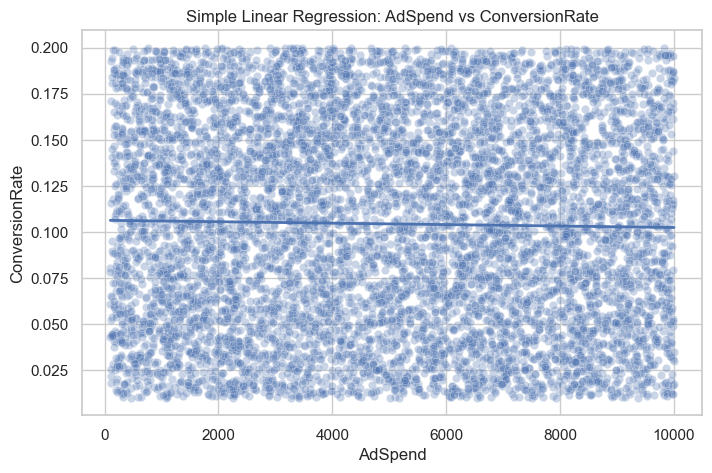

In [11]:
# Visualize the simple regression line
df_sorted = df.sort_values("AdSpend")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="AdSpend", y="ConversionRate", alpha=0.3)
plt.plot(df_sorted["AdSpend"], df_sorted["Pred_Simple"], linewidth=2)
plt.title("Simple Linear Regression: AdSpend vs ConversionRate")
plt.xlabel("AdSpend")
plt.ylabel("ConversionRate")
plt.show()

## Simple Model Interpretation

The regression line is almost flat.

The R² value is almost 0.

This means `AdSpend` alone explains almost none of the variation in `ConversionRate`.

This is an important finding, not a failure.

# 9. Residuals and Least Squares

A residual is the prediction error:

`Residual = Actual ConversionRate - Predicted ConversionRate`

Linear Regression finds the line that minimizes the total squared residuals.

In [12]:
# Calculate residuals and squared residuals
df["Residual_Simple"] = df["ConversionRate"] - df["Pred_Simple"]
df["Squared_Residual_Simple"] = df["Residual_Simple"] ** 2

# Sum of squared errors
sse_simple = df["Squared_Residual_Simple"].sum()

display(
    df[[
        "AdSpend",
        "ConversionRate",
        "Pred_Simple",
        "Residual_Simple",
        "Squared_Residual_Simple"
    ]].head()
)

print("Sum of Squared Errors:", sse_simple)

,AdSpend,ConversionRate,Pred_Simple,Residual_Simple,Squared_Residual_Simple
0,"6,497.8701",0.0880,0.1038,-0.0158,0.0002
1,"3,898.6686",0.1827,0.1048,0.0779,0.0061
2,"1,546.4296",0.0764,0.1057,-0.0293,0.0009
3,539.5259,0.0880,0.1061,-0.0181,0.0003
4,"1,678.0436",0.1099,0.1057,0.0043,0.0000


Sum of Squared Errors: 24.080198192094088


# 10. Multiple Linear Regression — Numeric Features

Now I use more numeric features instead of only `AdSpend`.

This checks whether customer, campaign, and engagement metrics improve prediction.

In [13]:
# Numeric features for the first multiple regression model
numeric_features = [
    "Age", "Income", "AdSpend", "ClickThroughRate", "WebsiteVisits",
    "PagesPerVisit", "TimeOnSite", "SocialShares", "EmailOpens",
    "EmailClicks", "PreviousPurchases", "LoyaltyPoints"
]

# Input and target
X_numeric = df[numeric_features]
y = df["ConversionRate"]

# Train/test split
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
numeric_model = LinearRegression()
numeric_model.fit(X_train_num, y_train_num)

# Predict
y_train_num_pred = numeric_model.predict(X_train_num)
y_test_num_pred = numeric_model.predict(X_test_num)

print("Numeric model trained.")
print("Training shape:", X_train_num.shape)
print("Testing shape:", X_test_num.shape)

Numeric model trained.
Training shape: (6400, 12)
Testing shape: (1600, 12)


In [14]:
# Helper function for regression metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Calculate train and test metrics
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train_num, y_train_num_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test_num, y_test_num_pred)

numeric_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

display(numeric_results)

,Dataset,MAE,RMSE,R2
0,Train,0.0478,0.0550,0.0019
1,Test,0.0468,0.0540,0.0015


## Numeric Model Interpretation

The train and test results are similar, so the model is not overfitting.

However, R² is still very close to 0.

This means the numeric features do not strongly explain `ConversionRate` using Linear Regression.

# 11. Add Categorical Features with One-Hot Encoding

Now I include:

- `Gender`
- `CampaignChannel`
- `CampaignType`

These are text columns, so they must be converted into numeric 0/1 columns using one-hot encoding.

In [15]:
# Clean feature selection
numeric_features_clean = [
    "Age", "Income", "AdSpend", "ClickThroughRate", "WebsiteVisits",
    "PagesPerVisit", "TimeOnSite", "SocialShares", "EmailOpens",
    "EmailClicks", "PreviousPurchases", "LoyaltyPoints"
]

categorical_features_clean = [
    "Gender", "CampaignChannel", "CampaignType"
]

features_clean = numeric_features_clean + categorical_features_clean

# Create clean X and y
X_clean = df[features_clean]
y_clean = df["ConversionRate"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X_clean, drop_first=True).astype(float)

print("Before encoding:", X_clean.shape)
print("After encoding:", X_encoded.shape)

display(X_encoded.head())

Before encoding: (8000, 15)
After encoding: (8000, 20)


,Age,Income,AdSpend,ClickThroughRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56.0000,"136,912.0000","6,497.8701",0.0439,0.0000,2.3990,7.3968,19.0000,6.0000,9.0000,4.0000,688.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,69.0000,"41,760.0000","3,898.6686",0.1557,42.0000,2.9171,5.3525,5.0000,2.0000,7.0000,2.0000,"3,459.0000",1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,46.0000,"88,456.0000","1,546.4296",0.2775,2.0000,8.2236,13.7949,0.0000,11.0000,2.0000,8.0000,"2,337.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,32.0000,"44,085.0000",539.5259,0.1376,47.0000,4.5409,14.6884,89.0000,2.0000,2.0000,0.0000,"2,463.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
4,60.0000,"83,964.0000","1,678.0436",0.2529,0.0000,2.0468,13.9934,6.0000,6.0000,6.0000,8.0000,"4,345.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


In [16]:
# Train/test split for encoded model
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_encoded,
    y_clean,
    test_size=0.2,
    random_state=42
)

# Train model
cat_model = LinearRegression()
cat_model.fit(X_train_cat, y_train_cat)

# Predict
y_train_cat_pred = cat_model.predict(X_train_cat)
y_test_cat_pred = cat_model.predict(X_test_cat)

# Evaluate
cat_train_mae, cat_train_mse, cat_train_rmse, cat_train_r2 = regression_metrics(y_train_cat, y_train_cat_pred)
cat_test_mae, cat_test_mse, cat_test_rmse, cat_test_r2 = regression_metrics(y_test_cat, y_test_cat_pred)

cat_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [cat_train_mae, cat_test_mae],
    "RMSE": [cat_train_rmse, cat_test_rmse],
    "R2": [cat_train_r2, cat_test_r2]
})

display(cat_results)

,Dataset,MAE,RMSE,R2
0,Train,0.0477,0.0550,0.0032
1,Test,0.0469,0.0541,-0.0023


## Categorical Model Interpretation

Adding categorical features did not improve the Linear Regression model.

The test R² is still close to 0, and it may even become negative.

A negative R² means the model performs worse than simply predicting the average `ConversionRate`.

# 12. Model Comparison

Now I compare the three regression models:

1. Simple Linear Regression with `AdSpend`
2. Multiple Regression with numeric features
3. Multiple Regression with numeric and categorical features

In [17]:
# Model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression: AdSpend only",
        "Multiple Regression: numeric features",
        "Multiple Regression: numeric + categorical features"
    ],
    "MAE": [
        mae_simple,
        test_mae,
        cat_test_mae
    ],
    "RMSE": [
        rmse_simple,
        test_rmse,
        cat_test_rmse
    ],
    "R2": [
        r2_simple,
        test_r2,
        cat_test_r2
    ]
})

display(model_comparison)

,Model,MAE,RMSE,R2
0,Simple Linear Regression: AdSpend only,0.0476,0.0549,0.0004
1,Multiple Regression: numeric features,0.0468,0.0540,0.0015
2,Multiple Regression: numeric + categorical fea...,0.0469,0.0541,-0.0023


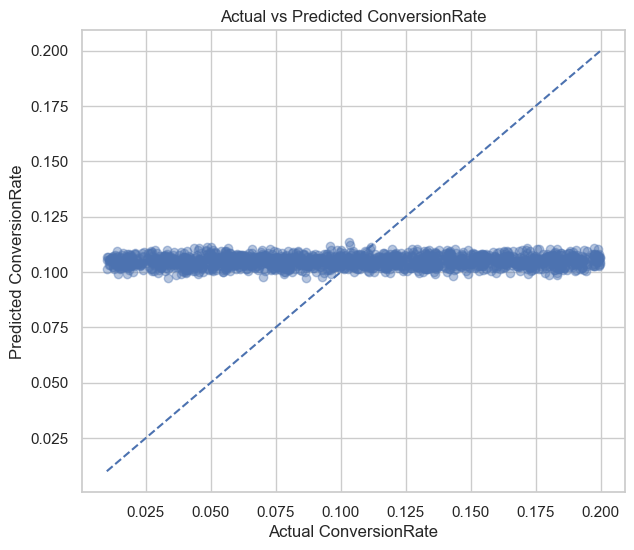

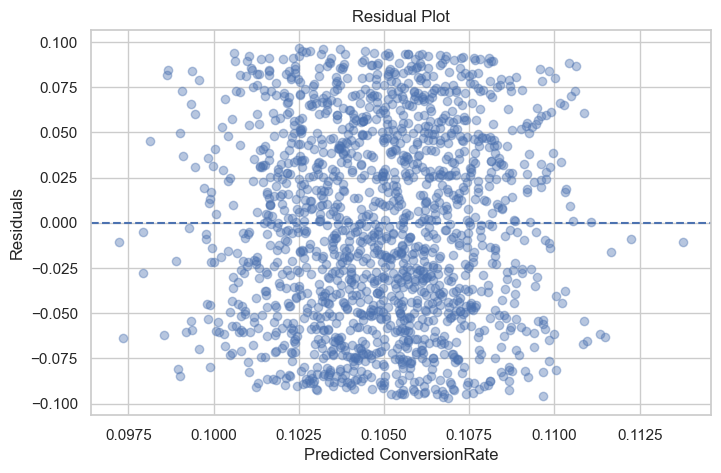

In [18]:
# Actual vs predicted plot for the numeric multiple regression model
plt.figure(figsize=(7, 6))

plt.scatter(y_test_num, y_test_num_pred, alpha=0.4)

# Diagonal reference line for perfect predictions
min_value = min(y_test_num.min(), y_test_num_pred.min())
max_value = max(y_test_num.max(), y_test_num_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title("Actual vs Predicted ConversionRate")
plt.xlabel("Actual ConversionRate")
plt.ylabel("Predicted ConversionRate")
plt.show()

# Residual plot
test_residuals = y_test_num - y_test_num_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_num_pred, test_residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted ConversionRate")
plt.ylabel("Residuals")
plt.show()

# 13. Final Business Conclusion

## Main Finding

Linear Regression is not a strong model for predicting `ConversionRate` in this dataset.

All three regression models have R² values close to 0.

This means the models explain very little of the variation in conversion rate.

## Business Interpretation

Ad spend, customer profile, engagement metrics, and campaign categories do not strongly predict `ConversionRate` using a linear regression approach.

The model mostly predicts close to the average conversion rate.

## Professional Conclusion

This regression analysis is useful as a learning and baseline exercise.

However, it should not be used as a final business prediction model.

## Recommended Next Step

The dataset has a binary target column:

`Conversion`

A better next step is to use classification, for example Logistic Regression, to predict whether a customer converts or not.

## Key Learning

Adding more features does not automatically create a better model.

A professional analyst must always evaluate model performance and interpret results carefully.